# CompCars Surveillance (CCTV) Fine-Grained Vehicle Classification
## Transfer Learning with EfficientNetB0



### 1. Imports & Environment Setup


In [1]:
import os
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


I0000 00:00:1788493809.289435    9347 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788493809.753655    9347 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788493814.179561    9347 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 2. Dataset Paths & Class Metadata (281 Classes)


In [19]:
DATA_DIR = "../compcars_cctv/extracted/sv_data_extracted/sv_data"
IMG_DIR = os.path.join(DATA_DIR, "image")

# Load make and model metadata (281 classes)
meta = loadmat(os.path.join(DATA_DIR, "sv_make_model_name.mat"))
models_meta = meta["sv_make_model_name"]

models_meta.shape

(281, 3)

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = len(models_meta)


In [4]:
# Extract human-readable Make + Model names
class_names = [f"{m[0][0]} {m[1][0]}" for m in models_meta]

print(f"Total Number of Classes: {NUM_CLASSES}")
print("Sample class names (first 10):")
for i, name in enumerate(class_names[:10]):
    print(f"  Class {i}: {name}")


Total Number of Classes: 281
Sample class names (first 10):
  Class 0: Besturn Besturn X80
  Class 1: Hafei Lubao
  Class 2: Audi Audi Q5
  Class 3: Audi Audi Q3
  Class 4: Audi Audi A7
  Class 5: Audi Audi A1
  Class 6: Buck Exclle
  Class 7: Buck encore
  Class 8: Buck Park Avenue
  Class 9: Buck Enclave


### 3. Load Training Dataset & Class Distribution


In [5]:
with open(os.path.join(DATA_DIR, "train_surveillance.txt"), "r") as f:
    train_lines = [line.strip() for line in f if line.strip()]

rows = []
for rel_path in train_lines:
    parts = rel_path.split("/")
    class_id = int(parts[0])
    image_name = parts[1]

    rows.append({
        "image": image_name,
        "class_id": class_id,
        "class_name": class_names[class_id - 1],
        "label": class_id - 1,
        "file_path": os.path.join(IMG_DIR, rel_path)
    })

df = pd.DataFrame(rows)
df.head()


,image,class_id,class_name,label,file_path
0,431e8997607115.jpg,1,Besturn Besturn X80,0,../compcars_cctv/extracted/sv_data_extracted/s...
1,dd2be86b09ee47.jpg,1,Besturn Besturn X80,0,../compcars_cctv/extracted/sv_data_extracted/s...
2,6b83b0deca175f.jpg,1,Besturn Besturn X80,0,../compcars_cctv/extracted/sv_data_extracted/s...
3,bac6732569714e.jpg,1,Besturn Besturn X80,0,../compcars_cctv/extracted/sv_data_extracted/s...
4,f747ed14094d48.jpg,1,Besturn Besturn X80,0,../compcars_cctv/extracted/sv_data_extracted/s...


In [ ]:
df["class_name"].value_counts().describe()

count    281.000000
mean     110.846975
std       84.234885
min       14.000000
25%       53.000000
50%       88.000000
75%      143.000000
max      565.000000
Name: count, dtype: float64

### 4. Model Architecture: EfficientNetB0 + Classification Head


In [7]:
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(NUM_CLASSES, dtype="float32", activation="softmax"),
])


I0000 00:00:1788493819.654455    9347 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 281)            │       359,961 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,409,532 (16.82 MB)

 Trainable params: 359,961 (1.37 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 5. Train / Validation Split (Stratified 80/20)


In [10]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")


Training images: 24918
Validation images: 6230


In [11]:
train_df.head()


,image,class_id,class_name,label,file_path
933,268810c8d6dedf.jpg,11,Buck Regal,10,../compcars_cctv/extracted/sv_data_extracted/s...
25028,3acff0205776ac.jpg,220,Cadillac Seville SLS,219,../compcars_cctv/extracted/sv_data_extracted/s...
19238,0d922fb273423d.jpg,163,Nissan Nissan NV200,162,../compcars_cctv/extracted/sv_data_extracted/s...
16768,bfc1620b36270c.jpg,138,MAZDA Mazda 6,137,../compcars_cctv/extracted/sv_data_extracted/s...
13926,5ed28120b0f2c3.jpg,116,Jianghuai Heyue,115,../compcars_cctv/extracted/sv_data_extracted/s...


In [12]:
val_df.head()


,image,class_id,class_name,label,file_path
5248,5ff9c7d60053d2.jpg,52,Chevy Epica,51,../compcars_cctv/extracted/sv_data_extracted/s...
4955,302d55290e7e1a.jpg,49,Baojun Baojun 630,48,../compcars_cctv/extracted/sv_data_extracted/s...
24044,f64c71bb9d87e3.jpg,210,Skoda Haorui,209,../compcars_cctv/extracted/sv_data_extracted/s...
24226,8139875ebcf61c.jpg,210,Skoda Haorui,209,../compcars_cctv/extracted/sv_data_extracted/s...
20946,c5005820f4cfe2.jpg,179,Peugeot Peugeot 408,178,../compcars_cctv/extracted/sv_data_extracted/s...


### 6. Data Augmentation & Generators


In [13]:
# Convert labels to strings (required for categorical class_mode)
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="file_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=CLASS_NAMES,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="file_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=CLASS_NAMES,
    class_mode="categorical",
    shuffle=False
)


Found 24918 validated image filenames belonging to 281 classes.
Found 6230 validated image filenames belonging to 281 classes.


### 7. Callbacks & Model Training


In [14]:
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-6
)


In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20


I0000 00:00:1788493827.253479    9347 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788493836.703891    9469 service.cc:153] XLA service 0x7199640341c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788493836.703929    9469 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788493837.123879    9469 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788493839.771318    9469 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788493840.300929    9469 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15734__.254
I0000 00:00:1788493846.018085    9576 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_Ma

131/390 ━━━━━━━━━━━━━━━━━━━━ 5:27 1s/step - accuracy: 0.0719 - loss: 5.1040

I0000 00:00:1788494035.526000    9466 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15734__.254
E0000 00:00:1788494037.902077    9466 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788494039.153867   10773 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads

E0000 00:00:1788494041.625600    9466 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788494044.096089    9466 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1965 - loss: 4.3140

I0000 00:00:1788494393.981198   12149 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 88 bytes spill stores, 44 bytes spill loads

I0000 00:00:1788494463.319493   12278 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads



390/390 ━━━━━━━━━━━━━━━━━━━━ 643s 2s/step - accuracy: 0.1965 - loss: 4.3140 - val_accuracy: 0.4531 - val_loss: 3.2038 - learning_rate: 0.0010
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 542s 1s/step - accuracy: 0.4620 - loss: 2.8628 - val_accuracy: 0.6377 - val_loss: 2.2763 - learning_rate: 0.0010
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.5870 - loss: 2.1845 - val_accuracy: 0.7074 - val_loss: 1.7610 - learning_rate: 0.0010
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.6489 - loss: 1.8105 - val_accuracy: 0.7591 - val_loss: 1.4558 - learning_rate: 0.0010
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.6927 - loss: 1.5624 - val_accuracy: 0.7960 - val_loss: 1.2352 - learning_rate: 0.0010
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 477s 1s/step - accuracy: 0.7184 - loss: 1.4001 - val_accuracy: 0.8238 - val_loss: 1.0699 - learning_rate: 0.0010
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 389s 996ms/step - accuracy: 0.7378 - loss: 1.2761 - v

### 8. Save Training History & Visualize Metrics


In [16]:
history_df = pd.DataFrame(history.history)
history_df.head()
history_df.to_csv("compcars_cctv_efficientnetb0.csv", index=False)


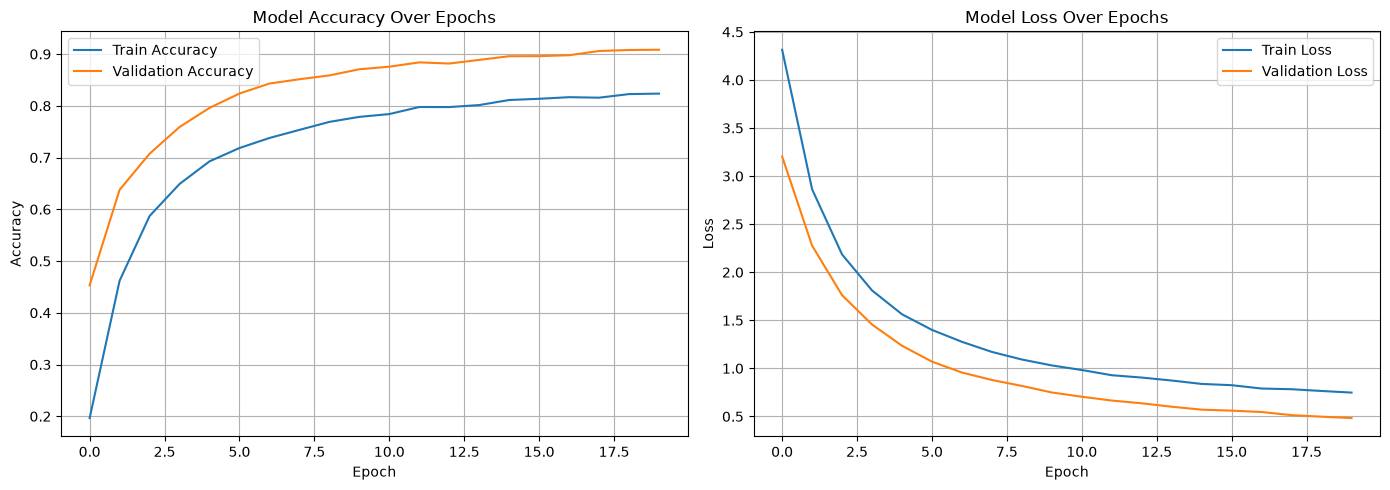

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 9. Model Evaluation on Official Surveillance Test Set


In [18]:
with open(os.path.join(DATA_DIR, "test_surveillance.txt"), "r") as f:
    test_lines = [line.strip() for line in f if line.strip()]

test_rows = []
for rel_path in test_lines:
    parts = rel_path.split("/")
    class_id = int(parts[0])
    test_rows.append({
        "image": parts[1],
        "class_id": class_id,
        "class_name": class_names[class_id - 1],
        "label": str(class_id - 1),
        "file_path": os.path.join(IMG_DIR, rel_path)
    })

test_df = pd.DataFrame(test_rows)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="file_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Found 13333 validated image filenames belonging to 281 classes.
208/209 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.9060 - loss: 0.4962

E0000 00:00:1788503135.071771    9468 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788503137.286341    9468 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788503139.784639    9468 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788503141.009232   32583 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads



209/209 ━━━━━━━━━━━━━━━━━━━━ 130s 618ms/step - accuracy: 0.9055 - loss: 0.4976
Test loss: 0.4976
Test accuracy: 0.9055


In [20]:
model.save('b0-first.keras')

In [ ]:
# Save model weights in standard Keras weights format (.weights.h5)
model.save_weights("b0-first.weights.h5")
print("Model weights successfully saved to b0-first.weights.h5")